# Feasibility Testing of Benchmark Test Problems

This notebook instantiates the five new benchmark test problems, generates random
test points within the bounds of each problem, evaluates them, and reports how many
satisfy all constraints.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import standard_evaluator as se
from standard_evaluator.evaluators.test import (
    SmallCircleFeasibleRegion,
    DisconnectedFeasibleRegions,
    G6Problem,
    G7Problem,
    SpeedReducer,
)

matlabengine not available.


In [3]:
def generate_random_sites(evaluator, n_samples: int, seed: int = None) -> pd.DataFrame:
    """Generate n_samples random points within the variable bounds of an evaluator.

    Parameters
    ----------
    evaluator : TestEvaluator
        An instantiated evaluator with an opt_problem.
    n_samples : int
        Number of samples to generate.
    seed : int
        Random seed for reproducibility.

    Returns
    -------
    pd.DataFrame
        DataFrame with columns matching the evaluator's input variable names,
        populated with uniformly random values within bounds.
    """
    rng = np.random.default_rng(seed)
    opt_problem = evaluator.opt_problem

    data = {}
    for var in opt_problem.variables:
        lb, ub = var.bounds
        data[var.name] = rng.uniform(lb, ub, size=n_samples)

    return pd.DataFrame(data)

In [4]:
def count_feasible(evaluator, sites: pd.DataFrame) -> int:
    """Evaluate sites and count how many satisfy all constraints (g <= 0).

    Parameters
    ----------
    evaluator : TestEvaluator
        An instantiated evaluator.
    sites : pd.DataFrame
        DataFrame of input sites to evaluate.

    Returns
    -------
    int
        Number of feasible points.
    """
    evaluator(sites)
    constraints = evaluator.opt_problem.constraints
    feasible_mask = (sites[constraints] <= 0).all(axis=1)
    return int(feasible_mask.sum())

## Instantiate all evaluators

In [5]:
evaluators = {
    "SmallCircleFeasibleRegion": SmallCircleFeasibleRegion(),
    "DisconnectedFeasibleRegions": DisconnectedFeasibleRegions(),
    "G6Problem": G6Problem(),
    "G7Problem": G7Problem(),
    "SpeedReducer": SpeedReducer(),
}

# Print basic info about each problem
for name, ev in evaluators.items():
    info = ev.test_info
    print(f"{name}: {info['n_vars']} vars, {info['n_constraints']} constraints, goal={info['test_goal']}")

SmallCircleFeasibleRegion: 2 vars, 1 constraints, goal=feasibility
DisconnectedFeasibleRegions: 2 vars, 1 constraints, goal=feasibility
G6Problem: 2 vars, 2 constraints, goal=optimization
G7Problem: 10 vars, 8 constraints, goal=optimization
SpeedReducer: 7 vars, 11 constraints, goal=optimization


## Generate, evaluate, and report feasibility

In [6]:
# Number of random test points to generate per problem
N_SAMPLES = 1_000_000

In [7]:
results = []

for name, ev in evaluators.items():
    sites = generate_random_sites(ev, N_SAMPLES)
    n_feasible = count_feasible(ev, sites)
    results.append({
        "Problem": name,
        "Variables": ev.test_info["n_vars"],
        "Constraints": ev.test_info["n_constraints"],
        "Samples": N_SAMPLES,
        "Feasible": n_feasible,
        "Feasible %": f"{100 * n_feasible / N_SAMPLES:.1f}%",
    })

results_df = pd.DataFrame(results)
results_df

,Problem,Variables,Constraints,Samples,Feasible,Feasible %
0,SmallCircleFeasibleRegion,2,1,1000000,17754,1.8%
1,DisconnectedFeasibleRegions,2,1,1000000,36859,3.7%
2,G6Problem,2,2,1000000,55,0.0%
3,G7Problem,10,8,1000000,3,0.0%
4,SpeedReducer,7,11,1000000,1857,0.2%


## Feasible region plots (2D problems)

In [8]:
def plot_feasible_region(evaluator, title: str, n_grid: int = 300):
    """Plot the feasible region for a 2D evaluator.

    Evaluates a dense grid and shades regions where all constraints <= 0.
    Also overlays the random sample points colored by feasibility.

    Parameters
    ----------
    evaluator : TestEvaluator
        A 2D evaluator (must have exactly 2 variables).
    title : str
        Plot title.
    n_grid : int
        Number of grid points per axis.
    """
    opt_problem = evaluator.opt_problem
    var1, var2 = opt_problem.variables[0], opt_problem.variables[1]

    x1 = np.linspace(var1.bounds[0], var1.bounds[1], n_grid)
    x2 = np.linspace(var2.bounds[0], var2.bounds[1], n_grid)
    X1, X2 = np.meshgrid(x1, x2)

    # Evaluate on the grid
    grid_sites = pd.DataFrame({var1.name: X1.ravel(), var2.name: X2.ravel()})
    evaluator(grid_sites)

    # Determine feasibility for each grid point
    constraints = opt_problem.constraints
    feasible = (grid_sites[constraints] <= 0).all(axis=1).values.reshape(X1.shape)

    # Also generate and evaluate the random samples for overlay
    sample_sites = generate_random_sites(evaluator, N_SAMPLES)
    evaluator(sample_sites)
    sample_feasible = (sample_sites[constraints] <= 0).all(axis=1)

    # Plot
    fig, ax = plt.subplots(1, 1, figsize=(7, 6))
    ax.contourf(X1, X2, feasible.astype(float), levels=[0.5, 1.5], colors=["#a8d5a2"], alpha=0.6)
    ax.contour(X1, X2, feasible.astype(float), levels=[0.5], colors=["green"], linewidths=1.5)

    # Scatter sample points
    ax.scatter(
        sample_sites.loc[~sample_feasible, var1.name],
        sample_sites.loc[~sample_feasible, var2.name],
        c="red", marker="x", s=30, label="Infeasible", alpha=0.7,
    )
    ax.scatter(
        sample_sites.loc[sample_feasible, var1.name],
        sample_sites.loc[sample_feasible, var2.name],
        c="blue", marker="o", s=40, label="Feasible", alpha=0.9,
    )

    ax.set_xlabel(var1.name)
    ax.set_ylabel(var2.name)
    ax.set_title(title)
    ax.legend()
    ax.set_aspect("equal" if var1.bounds == var2.bounds else "auto")
    plt.tight_layout()
    plt.show()

C:\Users\tf715b\AppData\Local\Temp\ipykernel_17240\3850242966.py:58: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
c:\dev\standard-evaluator\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


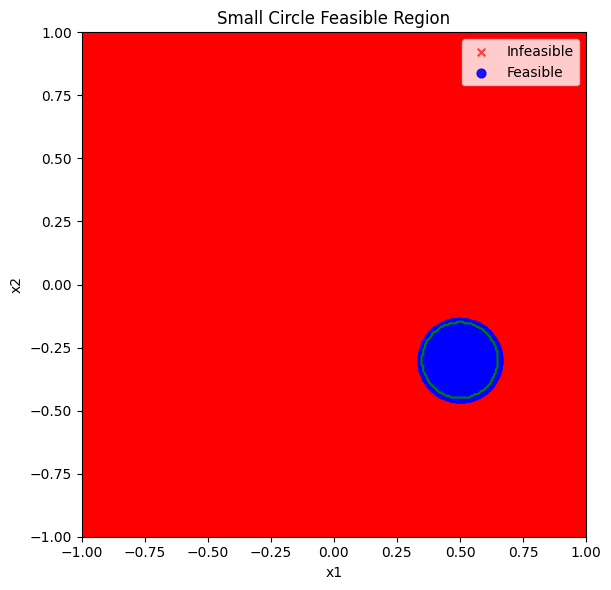

In [9]:
plot_feasible_region(evaluators["SmallCircleFeasibleRegion"], "Small Circle Feasible Region")

C:\Users\tf715b\AppData\Local\Temp\ipykernel_17240\3850242966.py:58: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
c:\dev\standard-evaluator\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


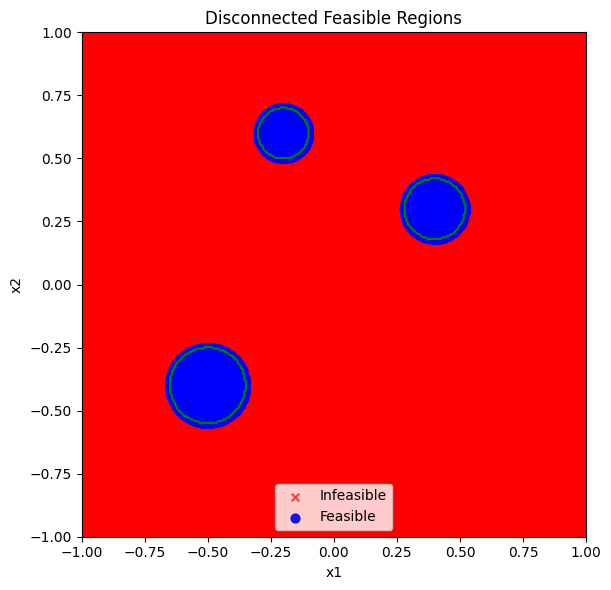

In [10]:
plot_feasible_region(evaluators["DisconnectedFeasibleRegions"], "Disconnected Feasible Regions")

C:\Users\tf715b\AppData\Local\Temp\ipykernel_17240\3850242966.py:58: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
c:\dev\standard-evaluator\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


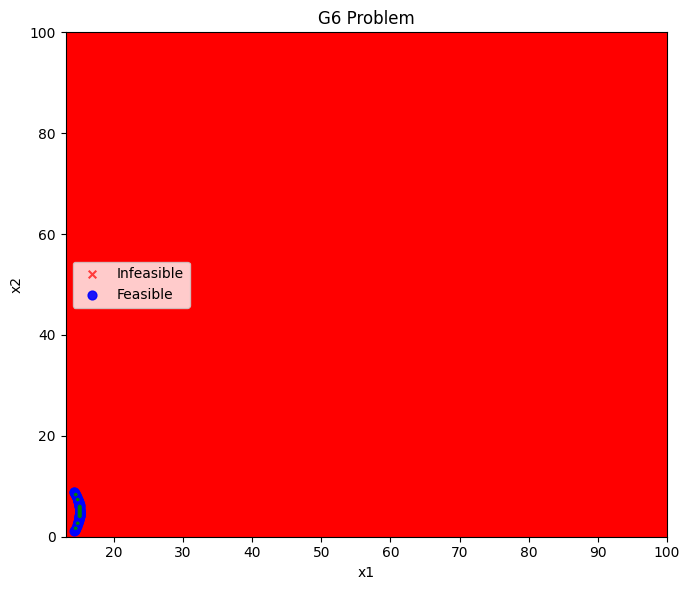

In [11]:
plot_feasible_region(evaluators["G6Problem"], "G6 Problem")

## 3D Infeasibility surface plots (2D problems)

The z-axis shows the L2 norm of constraint violation: $\|\max(g, 0)\|_2$.
Feasible points sit at z = 0.

In [12]:
%matplotlib widget

In [13]:
def plot_infeasibility_surface(evaluator, title: str, n_grid: int = 80):
    """Plot a 3D surface of infeasibility for a 2D evaluator.

    The z-axis represents the L2 norm of constraint violation:
        z = sqrt(sum(max(g_i, 0)^2))

    Feasible points have z = 0.

    Parameters
    ----------
    evaluator : TestEvaluator
        A 2D evaluator (must have exactly 2 variables).
    title : str
        Plot title.
    n_grid : int
        Number of grid points per axis.
    """
    opt_problem = evaluator.opt_problem
    var1, var2 = opt_problem.variables[0], opt_problem.variables[1]

    x1 = np.linspace(var1.bounds[0], var1.bounds[1], n_grid)
    x2 = np.linspace(var2.bounds[0], var2.bounds[1], n_grid)
    X1, X2 = np.meshgrid(x1, x2)

    # Evaluate on the grid
    grid_sites = pd.DataFrame({var1.name: X1.ravel(), var2.name: X2.ravel()})
    evaluator(grid_sites)

    # Compute L2 norm of constraint violation: sqrt(sum(max(g_i, 0)^2))
    constraints = opt_problem.constraints
    g_values = grid_sites[constraints].values
    violation = np.maximum(g_values, 0)
    infeasibility = np.sqrt(np.sum(violation**2, axis=1)).reshape(X1.shape)

    # Plot 3D surface
    fig = plt.figure(figsize=(9, 7))
    ax = fig.add_subplot(111, projection="3d")
    surf = ax.plot_surface(
        X1, X2, infeasibility,
        cmap="viridis", edgecolor="none", alpha=0.85,
    )
    fig.colorbar(surf, ax=ax, shrink=0.6, label="Infeasibility (L2)")

    ax.set_xlabel(var1.name)
    ax.set_ylabel(var2.name)
    ax.set_zlabel("Infeasibility")
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

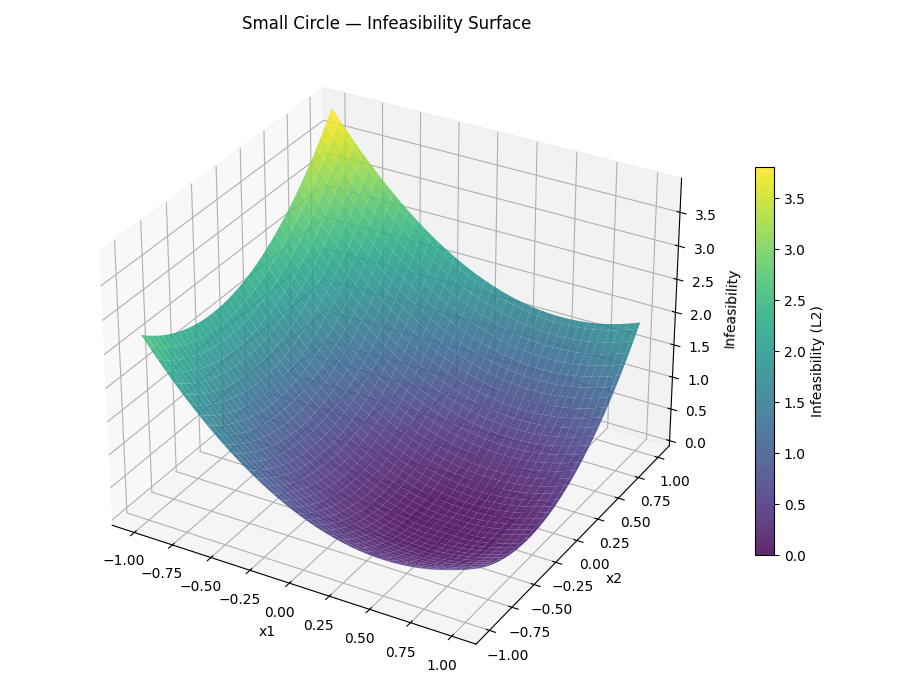

In [14]:
plot_infeasibility_surface(evaluators["SmallCircleFeasibleRegion"], "Small Circle — Infeasibility Surface")

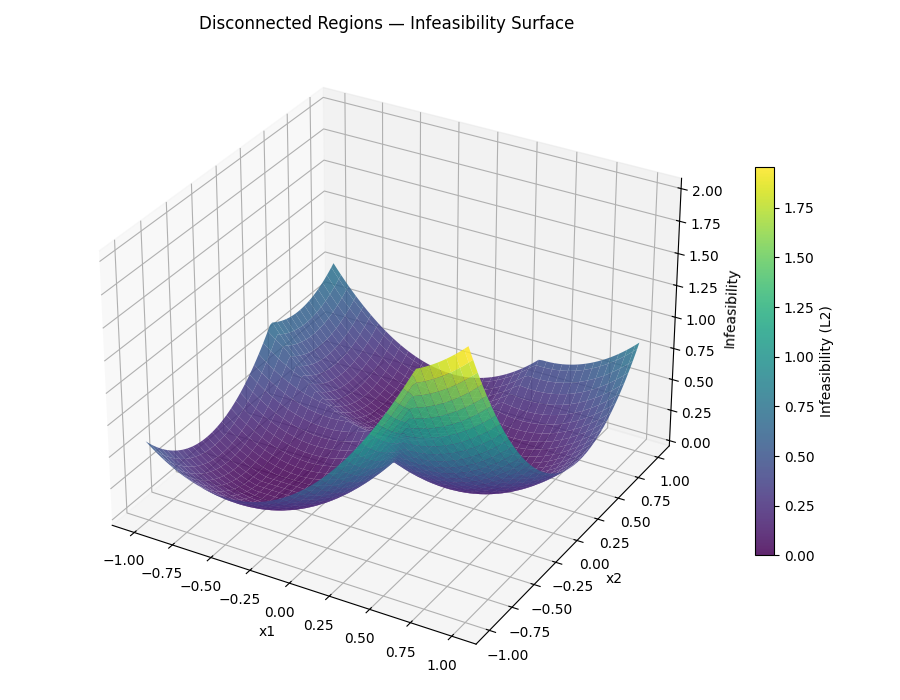

In [15]:
plot_infeasibility_surface(evaluators["DisconnectedFeasibleRegions"], "Disconnected Regions — Infeasibility Surface")

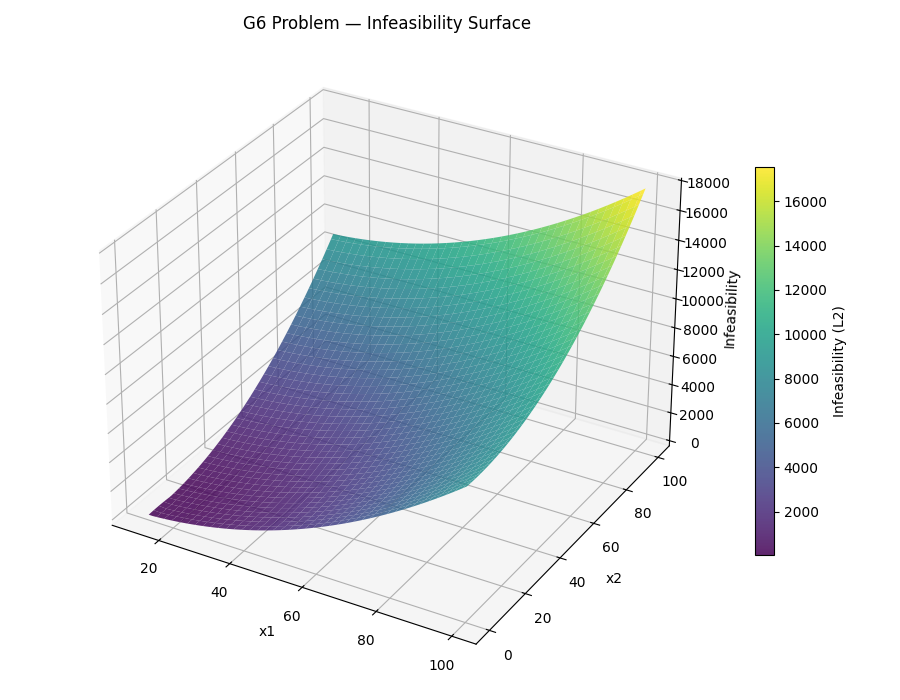

In [16]:
plot_infeasibility_surface(evaluators["G6Problem"], "G6 Problem — Infeasibility Surface")